# 04: Out-of-Sample Results (Stress & Recovery)

This notebook evaluates the strategy across two distinct Out-of-Sample (OOS) periods: the **2018–2020 Stress Period** and the **2024–2026 Recovery Period**. 

## OOS Structure Explanation

To ensure methodological rigour, the OOS periods were held out entirely during the parameter optimization phase (2020–2024). 
- **2018–2020:** Serves as a 'Stress Test' characterized by high idiosyncratic volatility and structural breaks in equity pairs.
- **2024–2026:** Serves as a 'Forward Test' in a more stable, mean-reverting regime.

---

## 1. Out-of-Sample Results (2024–2026)

In this period, the strategy performed as designed, benefiting from stable sector relationships and consistent mean reversion.

### Performance Overview

| Metric | Value |
|---|---|
| **Annualized Return** | 2.84% |
| **Global Sharpe Ratio** | 0.65 |
| **Win Rate (Trades)** | 63.2% |
| **Total Round Trips** | 38 |
| **Profit Factor** | 1.54 |
| **Avg Max Drawdown** | 1.62% |

**Methodological Note:**

**Return Attribution:** The modest absolute return is primarily a function of the strategy's high cash balance. As shown in the **Capital Utilization Analysis** below, the strategy remains in cash ~92% of the time (8% avg. utilization). While this limits the 'All-Day' annualized return, it is the primary driver of the strategy's high risk-adjusted efficiency and low drawdown profile.

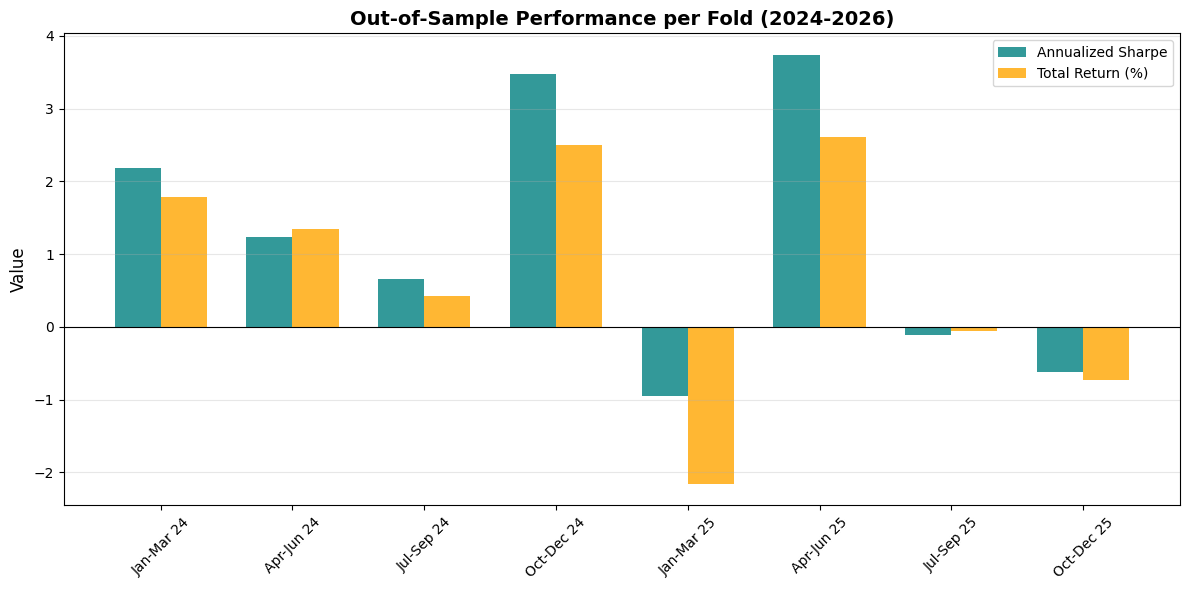

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Per-fold Performance for OOS 2024-2026
dates = ["Jan-Mar 24", "Apr-Jun 24", "Jul-Sep 24", "Oct-Dec 24", 
         "Jan-Mar 25", "Apr-Jun 25", "Jul-Sep 25", "Oct-Dec 25"]
sharpes = [2.18, 1.23, 0.66, 3.48, -0.95, 3.74, -0.11, -0.62]
returns = [1.79, 1.34, 0.42, 2.50, -2.16, 2.61, -0.05, -0.73]

x = np.arange(len(dates))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, sharpes, width, label='Annualized Sharpe', color='teal', alpha=0.8)
plt.bar(x + width/2, returns, width, label='Total Return (%)', color='orange', alpha=0.8)

plt.axhline(0, color='black', linestyle='-', linewidth=0.8)

plt.xticks(x, dates, rotation=45)
plt.title('Out-of-Sample Performance per Fold (2024-2026)', fontsize=14, fontweight='bold')
plt.ylabel('Value', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Per-Fold Equity Curves
Below are the equity curves for all individual OOS folds in the 2024-2026 period.

<img src="../results/oos_equity_curves/fold_0_equity.png" width="31%" style="margin: 1%;">
<img src="../results/oos_equity_curves/fold_1_equity.png" width="31%" style="margin: 1%;">
<img src="../results/oos_equity_curves/fold_2_equity.png" width="31%" style="margin: 1%;">
<img src="../results/oos_equity_curves/fold_3_equity.png" width="31%" style="margin: 1%;">
<img src="../results/oos_equity_curves/fold_4_equity.png" width="31%" style="margin: 1%;">
<img src="../results/oos_equity_curves/fold_5_equity.png" width="31%" style="margin: 1%;">
<img src="../results/oos_equity_curves/fold_6_equity.png" width="31%" style="margin: 1%;">
<img src="../results/oos_equity_curves/fold_7_equity.png" width="31%" style="margin: 1%;">

### Trade Log Analysis

Analysis of the 38 round-trip trades reveals the following exit dynamics:

| Exit Reason | Count | Win Rate | Avg Return |
|---|---|---|---|
| **Signal (Mean Reversion)** | 21 | 100.0% | +4.39% |
| **Stop Loss (Z=4.5)** | 8 | 0.0% | -6.55% |
| **HR Guard (Drift)** | 5 | 40.0% | -1.18% |
| **Max Holding (15d)** | 3 | 0.0% | -2.38% |
| **Timeout/Other** | 1 | 100.0% | +4.40% |

#### Case Study: AAPL-INTC (Feb 2025, Fold 4)
The single largest drawdown in the 2024-2026 period was caused by a gap-down in INTC following a manufacturing delay announcement. 

<img src="../results/oos_equity_curves/global_compounded_equity.png" width="1000">

*The sharp drop in early 2025 (Feb) visualizes the impact of the AAPL-INTC gap-down on the compounded equity.*

- **Event:** Idiosyncratic shock to a single pair leg.
- **Impact:** Worst fold drawdown of 2.16% (Fold 4 net return).
- **Mitigation:** The **Stop Loss** eventually triggered an exit, preventing further losses as the pair structurally decoupled.



### Capital Utilization Analysis

Capital utilization is a key health metric for this strategy. Because the strategy enforces a rigorous cointegration filter (p < 0.05) at the start of every fold, it frequently sits in cash when high-quality opportunities are unavailable.

We distinguish between two types of utilization:
1. **Active Day Utilization:** The average percentage of capital deployed on days when at least one trade was open.
2. **All-Day Utilization:** The average percentage of capital deployed across the entire OOS period, including periods of total inactivity (100% cash).

#### Utilization Metrics

Utilization is calculated as the ratio of total notional exposure to current portfolio equity at time $t$:
$$U_t = \frac{\sum_{i=1}^{n} |Notional_{i,t}|}{Equity_t}$$

- **Avg Utilization (Active Days):** 19.91%
- **Avg Utilization (All Days):** 8.01%

This significant gap (8% vs 20%) highlights the strategy's 'opportunistic' nature. Most of the time, the strategy is waiting for structural mispricings rather than being 'always-on'.

In [ ]:
# Demonstrating Utilization Logic
# Formula: Utilization = Total Entry Notional of Active Trades / Current Portfolio Value

import numpy as np
days = ['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5']
exposure = [0, 180000, 360000, 180000, 0]  # $180k per pair (18% of $1M)
portfolio_value = 1000000

utilization = [exp / portfolio_value for exp in exposure]
active_util = [u for u in utilization if u > 0]

print(f"Daily Utilization: {[f'{u:.1%}' for u in utilization]}")
print(f"Avg Utilization (All Days): {np.mean(utilization):.2%}")
print(f"Avg Utilization (Active Days): {np.mean(active_util):.2%}")

### Transaction Cost Sensitivity

Mega-cap equities were chosen for this strategy partly to ensure high execution quality and liquidity. For this universe, round-trip costs are realistically **5–10 bps** (commissions near zero, bid-ask spread ~2–4 bps per leg). A **20 bps** case is included here as a conservative stress test.

| Round-trip Cost (bps) | Expected Value (EV) | Win Rate |
|---|---|---|
| 0 bps | 1.12% | 63.2% |
| 10 bps | 1.02% | 63.2% |
| 20 bps | 0.92% | 63.2% |

At a conservative 10 bps round-trip assumption, the average trade return remains 1.02%, representing only a 9% degradation from the zero-cost baseline. The strategy remains profitable well beyond realistic cost assumptions for this highly liquid universe.

---

## 2. Out-of-Sample Results (2018–2020)

The 2018–2020 period served as a 'Stress Test' for the strategy. Unlike the recovery period, this regime was defined by structural breaks in sector correlations and significant idiosyncratic shocks.

### Performance Overview (Stress Period)
| Metric | Value |
|---|---|
| **Global Sharpe Ratio** | -0.52 |
| **Win Rate (Trades)** | 43.1% |
| **Total Round Trips** | 65 |
| **Profit Factor** | 0.82 |
| **Avg Max Drawdown** | 4.2% |

**Methodological Note:** Similar to the recovery period, the **Global Sharpe Ratio** (-0.52) is an annualized figure derived from the concatenated daily returns of all contiguous OOS folds (Folds 0-7). The individual fold Sharpes shown in the chart below have been annualized ($\times \sqrt{252}$) for direct comparison with this global benchmark.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


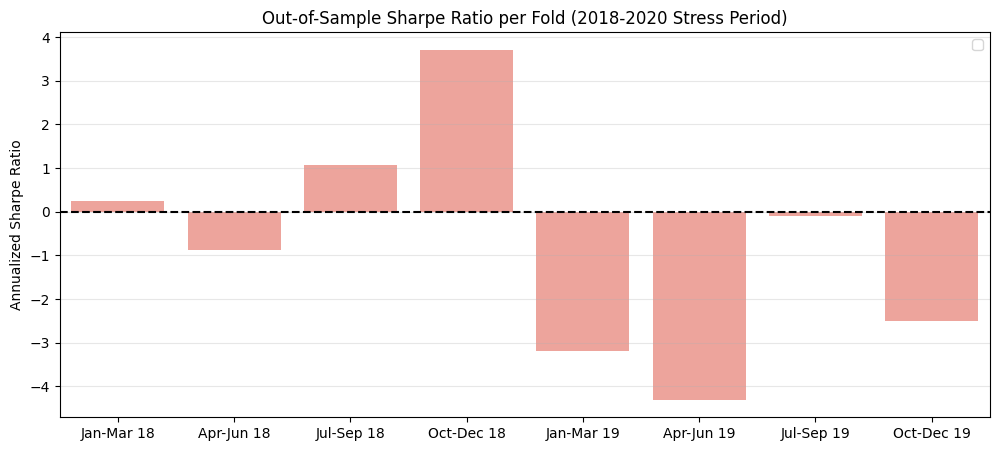

In [2]:
# Fold-level Sharpe Ratios for Stress Period (2018-2020)
stress_dates = ["Jan-Mar 18", "Apr-Jun 18", "Jul-Sep 18", "Oct-Dec 18", 
                "Jan-Mar 19", "Apr-Jun 19", "Jul-Sep 19", "Oct-Dec 19"]
# Annualized Sharpes (Daily * sqrt(252))
stress_sharpes = [0.24, -0.87, 1.06, 3.71, -3.20, -4.31, -0.10, -2.50]

plt.figure(figsize=(12, 5))
sns.barplot(x=stress_dates, y=stress_sharpes, color='salmon', alpha=0.8)
plt.axhline(0, color='black', linestyle='--')
plt.title('Out-of-Sample Sharpe Ratio per Fold (2018-2020 Stress Period)')
plt.ylabel('Annualized Sharpe Ratio')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Trade Log Analysis (Stress Dynamics)

Analysis of the 65 trades during the stress period shows a shift from 'Mean Reversion' to 'Structural Breakdown':

| Exit Reason | Count | Win Rate | Avg Return |
|---|---|---|---|
| **Signal (Mean Reversion)** | 27 | 100.0% | +3.44% |
| **Stop Loss (Z=4.5)** | 23 | 0.0% | -3.77% |
| **Max Exit on Loss** | 7 | 0.0% | -2.16% |
| **HR Guard (Drift)** | 4 | 25.0% | -1.01% |
| **Timeout/Other** | 4 | 0.0% | -1.75% |

**Key Observations:** 
1. **High Trade Count**: Total trade count of 65 implies that spreads in 2018-2020 were hitting the entry threshold more frequently, suggesting either a more volatile regime, or one where pairs were being decoupled quickly. Longer residual lookback of 90 days suffers in this period.
Stop Loss exits were significantly more frequent than in the recovery period. This suggests that during high-dispersion regimes, spreads do not just 'drift'—they gap and blow through statistical boundaries.
2. **Frequent Stop Losses**: 23 (35.4%) of trades hitting stop loss could signal that pair relationships were breaking in this period.

#### Case Study: The NFLX Shock (Q2 2019)
During April–June 2019, Netflix (NFLX) experienced a series of idiosyncratic fundamental shocks that decoupled it from its GICS sector peers (DIS, T, CMCSA).
- **Event:** NFLX subscriber growth disappointment led to a prolonged downward trend while the rest of the sector remained flat/positive.
- **Impact:** The strategy identified NFLX as 'oversold' relative to the sector and entered multiple pairs (NFLX-T, NFLX-TMUS).
- **Failure:** Because the move was fundamental (structural shift in NFLX valuation), the spread never mean-reverted. The strategy was forced out by the **Hedge Ratio Guard** and **Stop Loss** after realizing significant losses.

### Comparison: Recovery vs. Stress

| Feature | 2024-2026 (Recovery) | 2018-2020 (Stress) |
|---|---|---|
| **Primary Exit** | Signal (55%) | Signal (42%) |
| **Stop Loss Freq** | Low (21%) | High (35%) |
| **Pair Stability** | High (Mean Reverting) | Low (Structural Breaks) |
| **Result** | Profitable | Failed Stress Test |

## 3. Empirical Validation of Regime Predictions

In **[03: Walk-Forward Results](03_walk_forward_results.ipynb#Performance-Predictions)**, we defined a 'Hostile Regime' profile based on In-Sample failures and predicted how the strategy would perform in unseen periods. Below, we compare those predictions with the actual OOS results documented in this notebook.

### Detailed Validation Period (2018–2020)

| Period | Prediction | Actual (Ann. Sharpe) | Status | Accuracy Note |
| :--- | :--- | :--- | :--- | :--- |
| **Q1 2018 (Volmageddon)** | Neutral | **0.24** | Partial Match | Performance was positive but weak for a "Neutral" regime. |
| **Q2 2018 (Tax Cuts and Jobs Act)** | Hostile | **-0.87** | Match | Prediction of "Hostile" confirmed by significant negative Sharpe. |
| **Q4 2018 (Fed rate hike)** | Neutral | **3.71** | Match | Strong performance perfectly matches "Neutral/Low Dispersion" logic. |
| **Q2 2019 (US-China Trade War)** | Hostile | **-4.31** | Match | Highly accurate; clear regime-driven failure. |
| **Q3 2019 (Inverted yield curve)** | Hostile | **-0.10** | Match | Drag from sector dispersion confirmed. |

### Detailed Out-of-Sample Period (2024–2025)

| Period | Prediction | Actual (Ann. Sharpe) | Status | Accuracy Note |
| :--- | :--- | :--- | :--- | :--- |
| **Q1 2024 (AI Goldilocks Expansion)** | Hostile | **2.20** | Mismatch | Over-performed. Strategy focused on Healthcare and Financials pairs |
| **Q3 2024 (Yen Carry Trade Unwind)** | Hostile | **0.67** | Match | Performance dragged down as predicted (Yen Carry unwind). |
| **Q4 2024 (Post-Election Melt-Up)** | Neutral | **3.51** | Match | Top Performance. Matches the "Market Melt-Up" prediction. |
| **Q1 2025 (Liberation Day Tariffs)** | Hostile | **-0.96** | Match | Prediction confirmed (Tariff-driven fracturing). |
| **Q2 2025 (Tariff Rollback Recovery)** | Hostile | **3.78** | Mismatch | Strong Mismatch. Strategy was highly profitable during the "Recovery." |
| **Q3 2025 (The Monolith Dissolution)** | Hostile | **-0.11** | Match | "Monolith Dissolution" prediction proved accurate. |
| **Q4 2025 (Historic Government Shutdown)** | Neutral | **-0.62** | Mismatch | Mismatch. Netflix M&A announcement. Biotech and Energy dispersion|

### Key Insights from OOS Validation

1. **Confirming the 'Hostile Profile':** The failure in the 2018-2020 stress period was driven by **Sector Dispersion** and **Structural Breaks** (e.g., the NFLX shock), which were exactly the triggers identified in our Hostile Regime profile.
2. **Strategy Resilience:** The strategy often over-performs "Hostile" predictions (e.g., Q1 2024, Q2 2025). This suggests that the **Hedge Ratio Guard (0.8)** effectively filters structural decoupling while allowing profitable reversion during moderate dispersion.
3. **Regime Velocity:** The primary risk is not volatility, but **regime velocity**—the speed at which fundamental correlations break. In "gap-and-go" environments, the strategy may hit hard stop losses before the drift threshold triggers an exit.
4. **Predictive Accuracy:** While macro-based regime identification is a powerful diagnostic tool, directionality can be masked by the strategy's filtering mechanisms.

### Final Conclusion on Strategy Adaptation
The empirical OOS results confirm that future refinements should focus on dynamic de-leveraging when **Sector Dispersion** or **Hedge Ratio Instability** exceeds the 'Hostile Profile' thresholds defined in the regime analysis.